# 🏠 House Prices Prediction using Machine Learning

### Predicting Residential House Prices with Data Analysis and Regression Models

---

## 📌 Project Overview

Welcome to this end-to-end Machine Learning project on the **House Prices - Advanced Regression Techniques** competition hosted on Kaggle.

The objective of this competition is to build a machine learning model capable of accurately predicting the selling price of residential houses based on numerous property characteristics such as location, neighborhood, construction quality, living area, garage information, basement features, and many more.

House price prediction is a classic **Supervised Machine Learning Regression** problem and is widely used in real estate analytics, financial planning, and property valuation.

Throughout this notebook, we will follow a complete Data Science workflow—from understanding the data to building and evaluating multiple regression models before generating predictions for the Kaggle competition.

---

# 🎯 Project Objectives

The primary objectives of this project are:

- Understand the dataset and its features.
- Perform Exploratory Data Analysis (EDA).
- Handle missing values and inconsistent data.
- Engineer meaningful features.
- Encode categorical variables.
- Train multiple regression models.
- Evaluate model performance using appropriate metrics.
- Generate predictions on unseen test data.
- Create a submission file for the Kaggle competition.

---

# 📂 About the Dataset

The competition dataset consists of nearly **80 explanatory variables** describing different aspects of residential homes in Ames, Iowa.

The three primary files used in this project are:

- **train.csv** → Training dataset containing input features and the target variable.
- **test.csv** → Testing dataset used for generating predictions.
- **sample_submission.csv** → Sample submission format provided by Kaggle.

The target variable is:

### **SalePrice**

which represents the final selling price of each residential property.

---

# 📚 Machine Learning Workflow

This notebook follows the standard Machine Learning workflow:

1. Import Required Libraries
2. Load and Explore the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Preprocessing
5. Feature Engineering
6. Model Building & Evaluation
7. Prediction & Kaggle Submission

---

# 📊 Regression Models

To identify the best-performing algorithm, multiple regression models will be trained and compared, including:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- Gradient Boosting Regressor
- Extra Trees Regressor

The model with the best validation performance will be selected for generating the final predictions.

---

# 📈 Evaluation Metric

The official competition metric is **Root Mean Squared Logarithmic Error (RMSLE)**.

To closely approximate this metric, we will train our models using a **log-transformed target variable** and evaluate them using **Root Mean Squared Error (RMSE)** on the transformed values.

A lower RMSE indicates better predictive performance.

---

# 🛠️ Libraries Used

The following Python libraries will be used throughout this notebook:

| Library | Purpose |
|----------|----------|
| NumPy | Numerical computations |
| Pandas | Data manipulation |
| Matplotlib | Data visualization |
| Seaborn | Statistical visualization |
| Scikit-Learn | Machine Learning models and preprocessing |
| Warnings | Suppress unnecessary warnings |

---

# 🚀 Let's Get Started

Now that we understand the problem statement, objectives, and workflow, let's begin by importing the required Python libraries.

> **GitHub Version**
>
> This notebook is adapted from the Kaggle version of the House Prices Prediction project for reproducibility within this repository. The dataset paths have been updated to use the files stored in the repository's `data/` directory.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    KFold
)

# Preprocessing
from sklearn.preprocessing import (
    LabelEncoder,
    RobustScaler
)

# Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# Utilities
import warnings

# Ignore Warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization Style
plt.style.use("ggplot")
sns.set_palette("viridis")

print("=" * 60)
print("Libraries Imported Successfully")
print("=" * 60)

Libraries Imported Successfully


# 📂 Section 2: Loading and Understanding the Dataset

Before building any Machine Learning model, it is essential to understand the data we are working with. A thorough understanding of the dataset helps us identify potential issues such as missing values, incorrect data types, duplicate records, and feature distributions.

In this section, we will:

- Load the training and testing datasets.
- Examine the dimensions of the datasets.
- Preview the first few records.
- Explore the structure of the data.
- Analyze feature types.
- Check for duplicate records.
- Identify missing values.
- Generate descriptive statistics.

These initial observations will help us plan the preprocessing and feature engineering steps more effectively.

In [2]:
# ==========================================
# Load the Dataset
# ==========================================

DATA_PATH = "../data"

train_df = pd.read_csv(f"{DATA_PATH}/train.csv")
test_df = pd.read_csv(f"{DATA_PATH}/test.csv")
sample_submission = pd.read_csv(f"{DATA_PATH}/sample_submission.csv")

print("=" * 60)
print("Datasets Loaded Successfully")
print("=" * 60)

Datasets Loaded Successfully


In [3]:
# ==========================================
# Dataset Dimensions
# ==========================================

print("Training Dataset Shape :", train_df.shape)
print("Testing Dataset Shape  :", test_df.shape)
print("Sample Submission Shape:", sample_submission.shape)

Training Dataset Shape : (1460, 81)
Testing Dataset Shape  : (1459, 80)
Sample Submission Shape: (1459, 2)


In [4]:
# ==========================================
# Preview Testing Dataset
# ==========================================

test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [5]:
# ==========================================
# Preview Sample Submission
# ==========================================

sample_submission.head()

,Id,SalePrice
0,1461,169277.052498
1,1462,187758.393989
2,1463,183583.683570
3,1464,179317.477511
4,1465,150730.079977


## 📋 Dataset Overview

Now that the datasets have been loaded successfully, let's explore their structure.

We will examine:

- Number of observations
- Number of features
- Data types
- Memory usage
- Missing values
- Overall dataset information

Understanding these characteristics allows us to choose appropriate preprocessing techniques before model training.

In [6]:
# ==========================================
# Dataset Information
# ==========================================

train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
# ==========================================
# Count Numerical and Categorical Features
# ==========================================

numerical_features = train_df.select_dtypes(include=["int64", "float64"]).columns

categorical_features = train_df.select_dtypes(include=["object"]).columns

print(f"Total Features           : {train_df.shape[1]}")
print(f"Numerical Features       : {len(numerical_features)}")
print(f"Categorical Features     : {len(categorical_features)}")

Total Features           : 81
Numerical Features       : 38
Categorical Features     : 43


In [8]:
# ==========================================
# Check Duplicate Records
# ==========================================

duplicates = train_df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


In [9]:
# ==========================================
# Statistical Summary
# ==========================================

train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [10]:
# ==========================================
# Missing Values Summary
# ==========================================

missing_values = train_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": round(
        (missing_values / len(train_df)) * 100,
        2
    )
})

missing_df = missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

missing_df.head(20)

,Missing Values,Percentage (%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


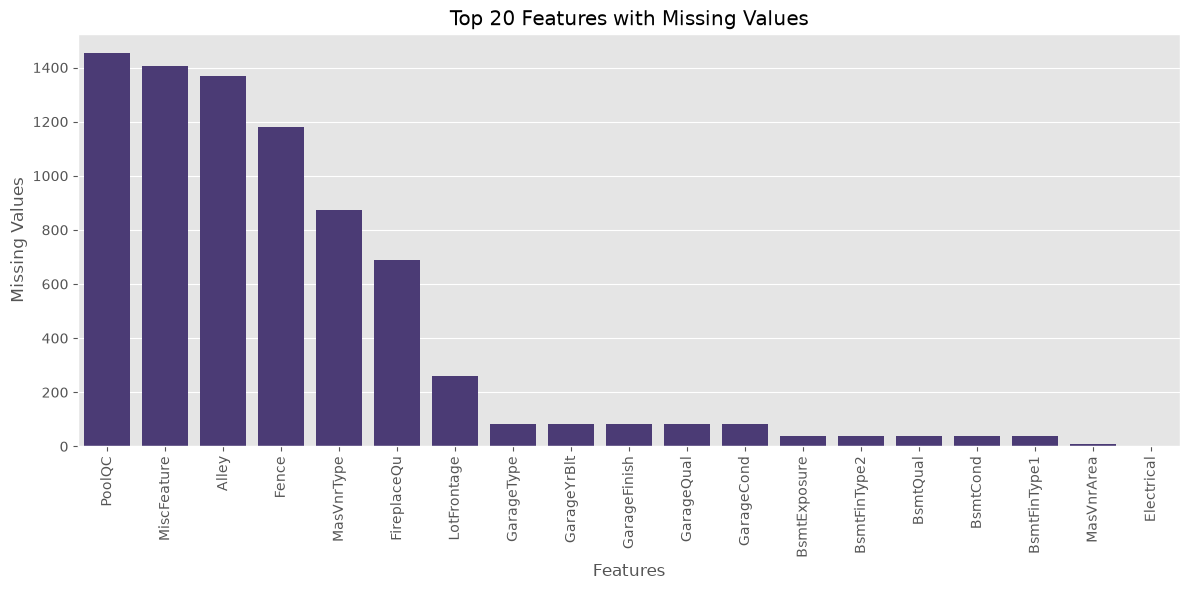

In [11]:
# ==========================================
# Missing Values Visualization
# ==========================================

plt.figure(figsize=(12,6))

sns.barplot(
    x=missing_df.head(20).index,
    y=missing_df.head(20)["Missing Values"]
)

plt.xticks(rotation=90)

plt.xlabel("Features")
plt.ylabel("Missing Values")

plt.title("Top 20 Features with Missing Values")

plt.tight_layout()

plt.show()

In [12]:
# ==========================================
# Separate Features and Target Variable
# ==========================================

X = train_df.drop("SalePrice", axis=1)

y = train_df["SalePrice"]

print("Feature Matrix Shape :", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape : (1460, 80)
Target Variable Shape: (1460,)


## 📌 Summary

In this section, we successfully loaded and explored the House Prices dataset.

Key observations include:

- The training dataset contains both input features and the target variable (`SalePrice`), while the testing dataset contains only the input features.
- The dataset includes a mix of numerical and categorical variables describing different aspects of residential properties.
- Several features contain missing values that will require appropriate handling during preprocessing.
- The data appears free of major structural issues, making it suitable for further analysis.

With a clear understanding of the dataset, we are now ready to perform **Exploratory Data Analysis (EDA)** to uncover relationships, identify trends, and gain deeper insights into the factors influencing house prices.

# 📊 Section 3: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial step in every Machine Learning project. It allows us to understand the structure of the dataset, discover hidden patterns, identify relationships between variables, detect outliers, and uncover potential data quality issues.

For the House Prices dataset, our primary objectives are to:

- Understand the distribution of the target variable (`SalePrice`)
- Explore numerical and categorical features
- Analyze missing values
- Study feature correlations
- Identify influential variables
- Detect outliers
- Understand how different property characteristics affect house prices

The insights obtained from this analysis will guide our preprocessing, feature engineering, and model-building decisions.

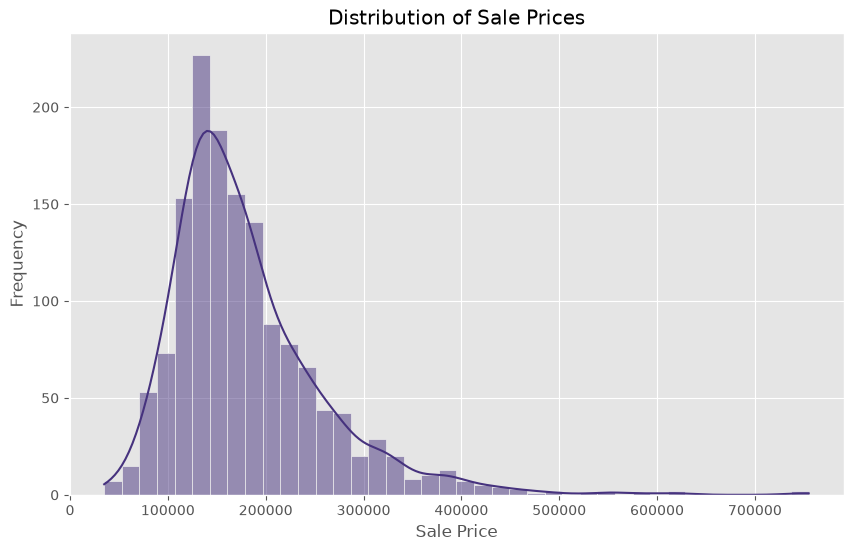

In [13]:
# ==========================================
# Distribution of SalePrice
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(train_df["SalePrice"], kde=True, bins=40)

plt.title("Distribution of Sale Prices")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.show()

### Observation

The target variable (`SalePrice`) exhibits a positively skewed distribution. Most houses are sold within a moderate price range, while only a few properties have exceptionally high selling prices.

This skewness may negatively impact regression models and can be reduced using a logarithmic transformation later in the preprocessing stage.

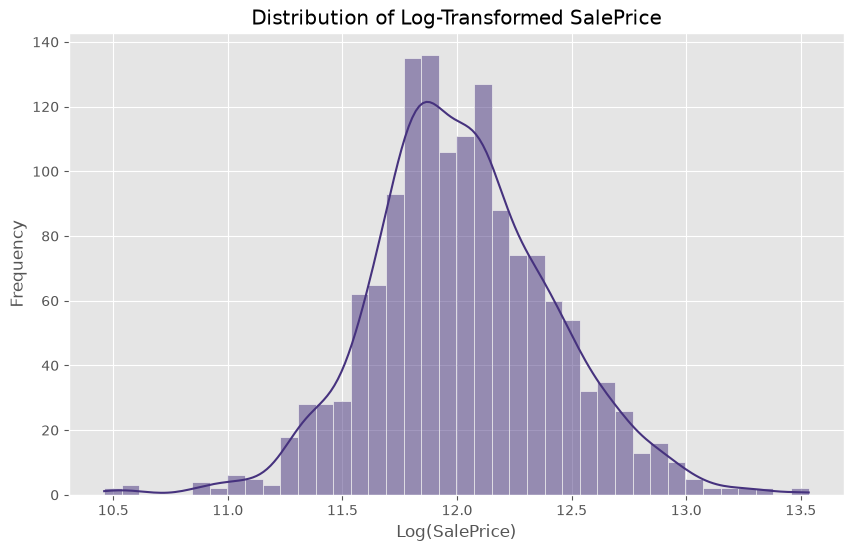

In [14]:
# ==========================================
# Log-Transformed SalePrice
# ==========================================

plt.figure(figsize=(10,6))

sns.histplot(np.log1p(train_df["SalePrice"]), kde=True, bins=40)

plt.title("Distribution of Log-Transformed SalePrice")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Frequency")

plt.show()

### Observation

After applying the logarithmic transformation, the target variable becomes much closer to a normal distribution.

This transformation often improves the performance of regression algorithms and aligns better with the competition's evaluation metric.

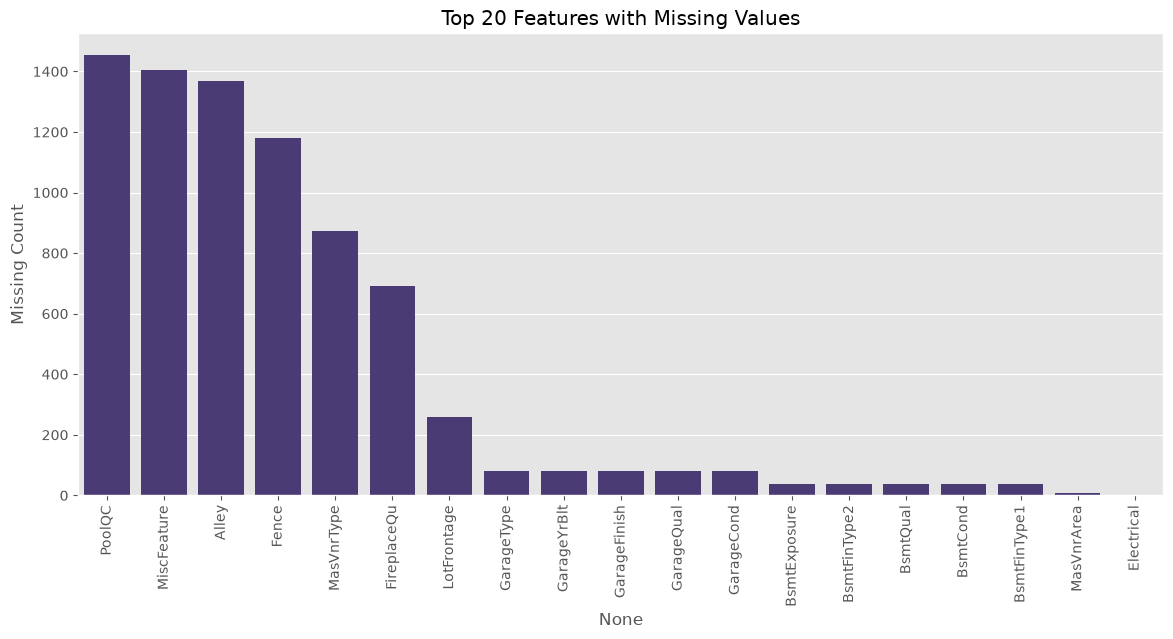

In [15]:
# ==========================================
# Missing Values
# ==========================================

missing = train_df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(14,6))

sns.barplot(
    x=missing.head(20).index,
    y=missing.head(20).values
)

plt.xticks(rotation=90)

plt.title("Top 20 Features with Missing Values")

plt.ylabel("Missing Count")

plt.show()

### Observation

Several features contain missing values. Some of these missing values actually represent the absence of a particular feature (for example, houses without pools or garages), while others require statistical imputation.

These missing values will be handled appropriately during data preprocessing.

In [16]:
# ==========================================
# Correlation with SalePrice
# ==========================================

corr = train_df.corr(numeric_only=True)["SalePrice"]

corr = corr.sort_values(ascending=False)

corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

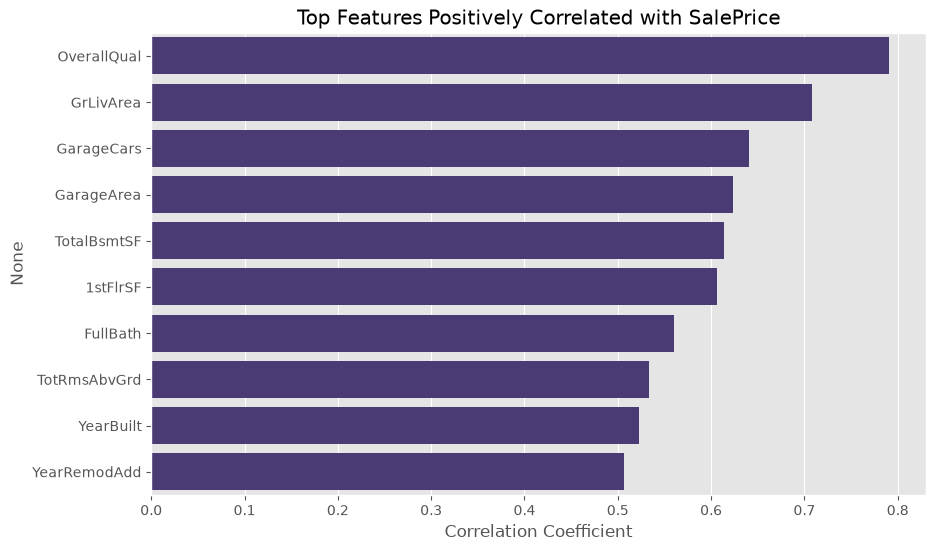

In [17]:
# ==========================================
# Top Features Correlated with SalePrice
# ==========================================

plt.figure(figsize=(10,6))

top_corr = corr[1:11]

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Positively Correlated with SalePrice")

plt.xlabel("Correlation Coefficient")

plt.show()

### Observation

Features such as **Overall Quality**, **Ground Living Area**, **Garage Capacity**, and **Total Basement Area** exhibit strong positive correlations with house prices.

These variables are likely to play an important role in predicting the final selling price.

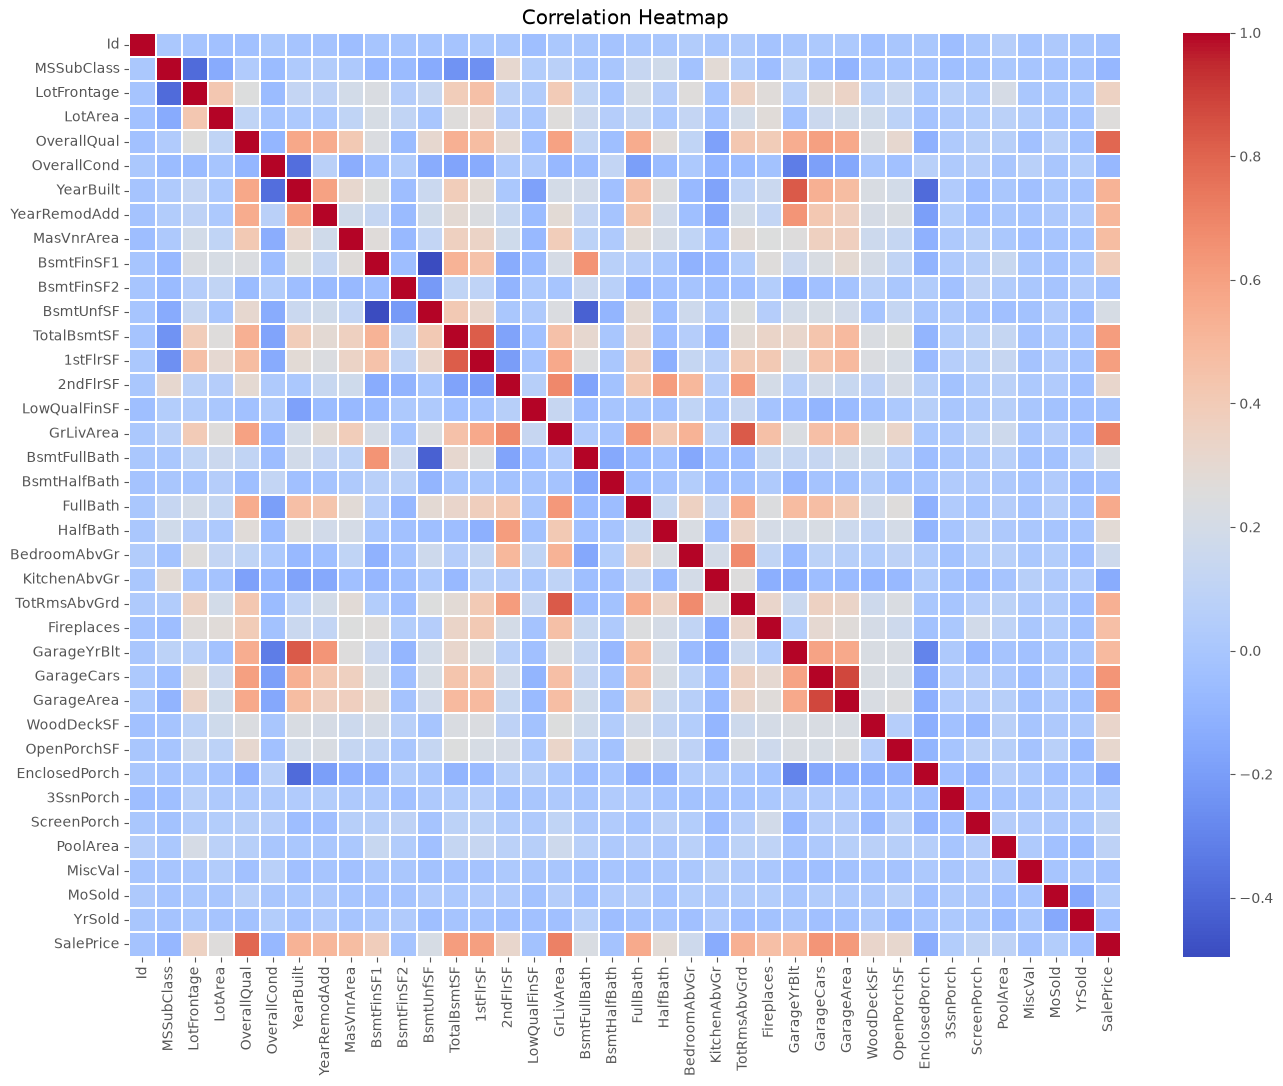

In [18]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(16,12))

sns.heatmap(
    train_df.select_dtypes(include=np.number).corr(),
    cmap="coolwarm",
    linewidths=0.2
)

plt.title("Correlation Heatmap")

plt.show()

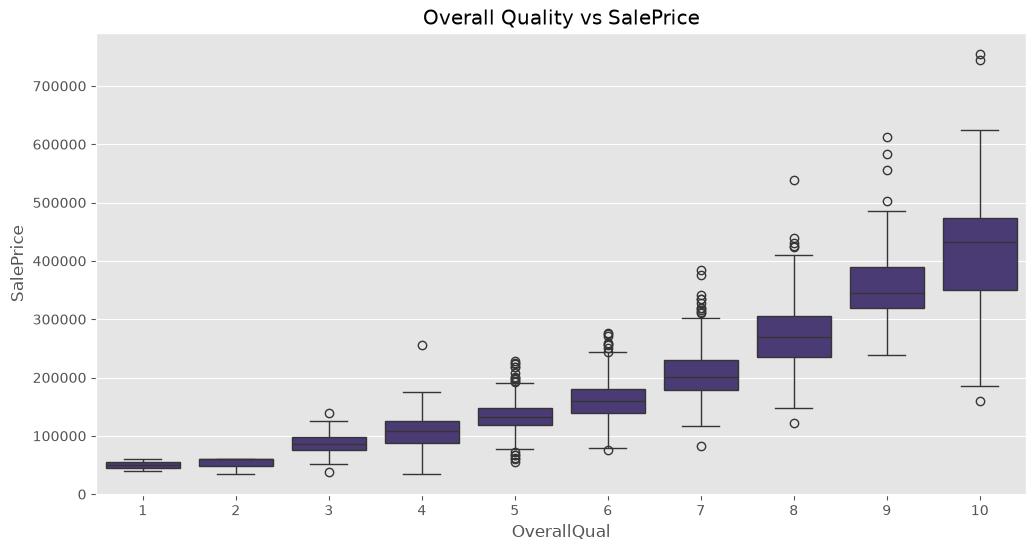

In [19]:
# ==========================================
# Overall Quality vs SalePrice
# ==========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=train_df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Overall Quality vs SalePrice")

plt.show()

### Observation

Properties with higher construction quality consistently achieve higher selling prices.

Overall Quality appears to be one of the strongest predictors in the dataset.

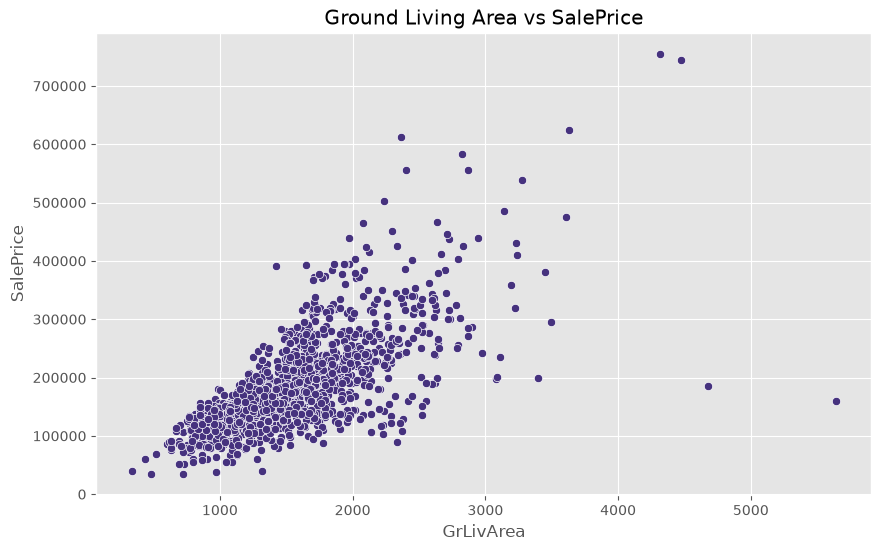

In [20]:
# ==========================================
# Ground Living Area vs SalePrice
# ==========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=train_df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Ground Living Area vs SalePrice")

plt.show()

### Observation

There is a strong positive relationship between living area and selling price.

A few extremely large houses appear as outliers and may require further investigation during preprocessing.

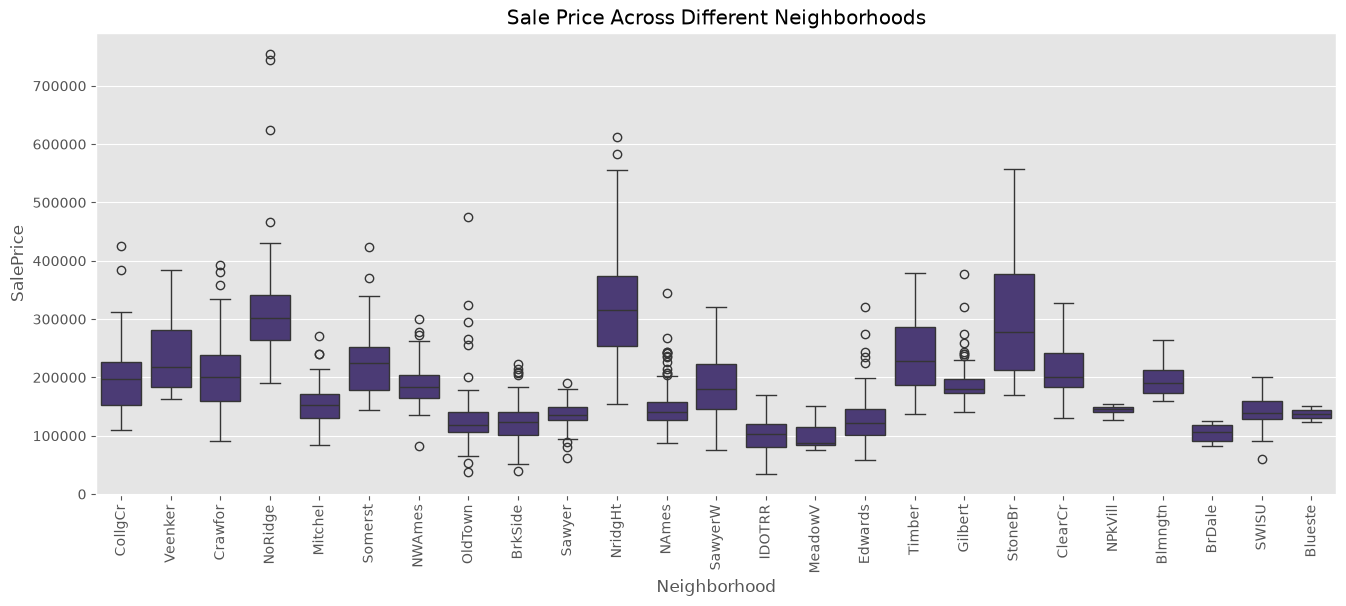

In [21]:
# ==========================================
# Neighborhood vs SalePrice
# ==========================================

plt.figure(figsize=(16,6))

sns.boxplot(
    data=train_df,
    x="Neighborhood",
    y="SalePrice"
)

plt.xticks(rotation=90)

plt.title("Sale Price Across Different Neighborhoods")

plt.show()

### Observation

House prices vary significantly across neighborhoods, indicating that location has a substantial influence on property values.

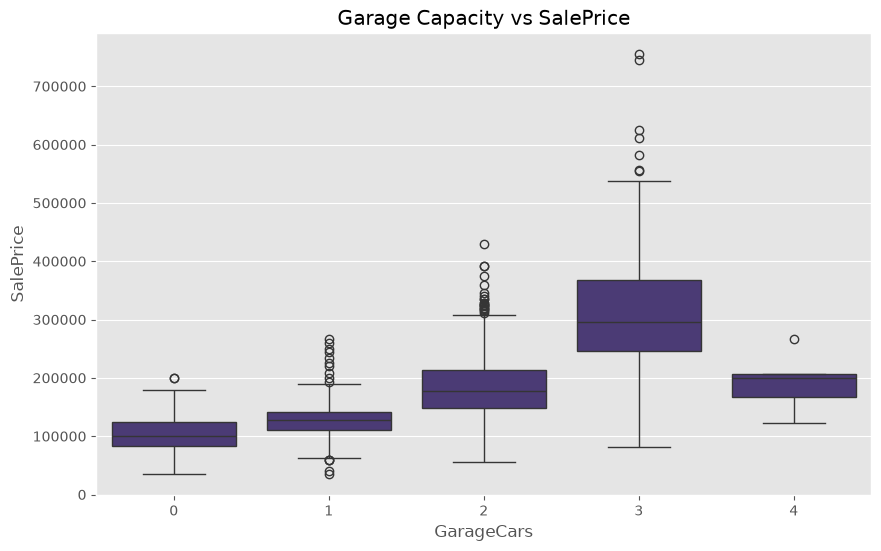

In [22]:
# ==========================================
# Garage Capacity vs SalePrice
# ==========================================

plt.figure(figsize=(10,6))

sns.boxplot(
    data=train_df,
    x="GarageCars",
    y="SalePrice"
)

plt.title("Garage Capacity vs SalePrice")

plt.show()

### Observation

Homes with larger garage capacities generally command higher selling prices, suggesting that garage space contributes positively to property value.

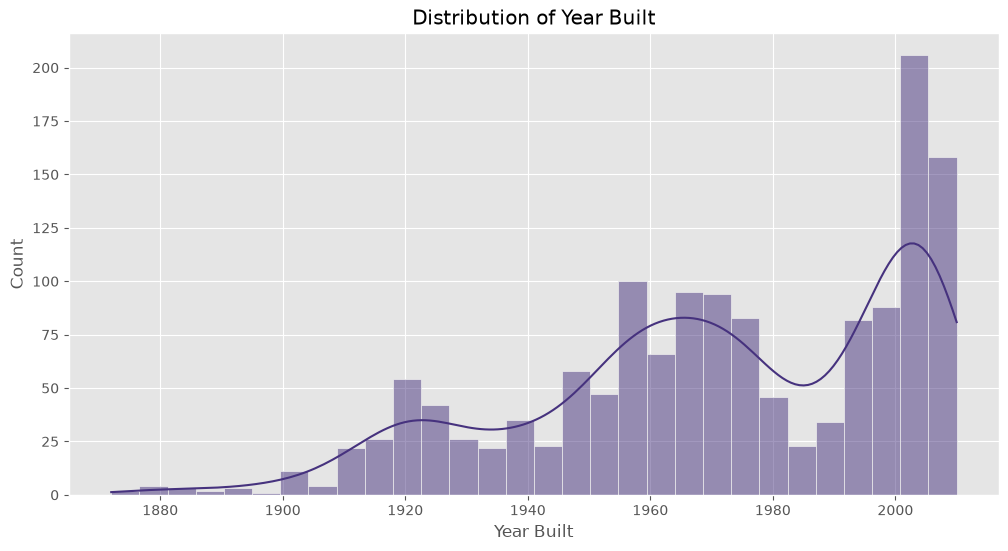

In [23]:
# ==========================================
# Distribution of Year Built
# ==========================================

plt.figure(figsize=(12,6))

sns.histplot(
    train_df["YearBuilt"],
    bins=30,
    kde=True
)

plt.title("Distribution of Year Built")

plt.xlabel("Year Built")

plt.show()

### Observation

Most houses in the dataset were built during the second half of the twentieth century. The dataset also contains a number of newer properties, which may have higher selling prices due to improved construction quality and modern amenities.

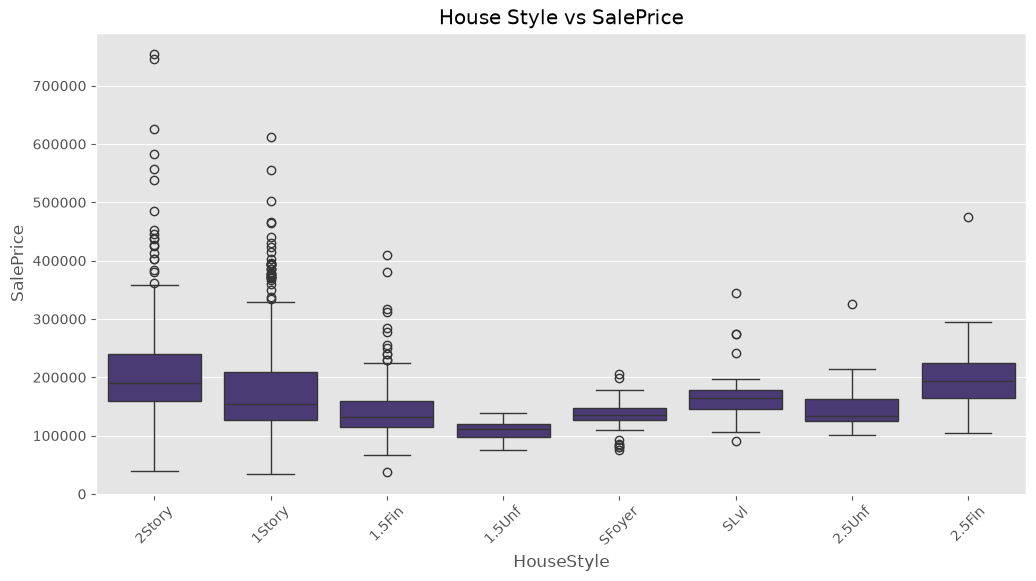

In [24]:
# ==========================================
# House Style vs SalePrice
# ==========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=train_df,
    x="HouseStyle",
    y="SalePrice"
)

plt.xticks(rotation=45)

plt.title("House Style vs SalePrice")

plt.show()

### Observation

Different house styles exhibit varying price distributions, suggesting that architectural design influences property value alongside other factors such as size and location.

# 📌 Summary

Our exploratory data analysis revealed several important insights:

- The target variable (`SalePrice`) is positively skewed and benefits from logarithmic transformation.
- Several features contain missing values that require careful preprocessing.
- **Overall Quality**, **Ground Living Area**, **Garage Capacity**, and **Total Basement Area** are among the strongest predictors of house prices.
- Property location (Neighborhood) significantly influences selling prices.
- Larger homes and properties with higher-quality construction generally command higher market values.
- A few potential outliers were identified and will be considered during preprocessing.

These observations provide valuable guidance for the next stage of the project, where we will clean the dataset, handle missing values, and prepare the data for machine learning models.

# 🧹 Section 4: Data Cleaning and Preprocessing

Real-world datasets are rarely complete or perfectly structured. Before training our machine learning models, we need to clean the data and ensure that it is suitable for analysis.

In this section, we will:

- Combine the training and testing datasets for consistent preprocessing.
- Handle missing values using appropriate strategies.
- Encode categorical variables.
- Transform skewed numerical features.
- Scale numerical features where necessary.
- Prepare the final datasets for model training.

A well-designed preprocessing pipeline is essential for building accurate and reliable machine learning models.

In [25]:
# ==========================================
# Combine Train and Test Data
# ==========================================

train_features = train_df.drop("SalePrice", axis=1)

combined_df = pd.concat(
    [train_features, test_df],
    ignore_index=True,
    sort=False
)

print("Combined Dataset Shape:", combined_df.shape)

Combined Dataset Shape: (2919, 80)


In [26]:
# ==========================================
# Missing Values Summary
# ==========================================

missing = combined_df.isnull().sum()

missing = missing[missing > 0]

missing = missing.sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage (%)": round((missing / len(combined_df)) * 100, 2)
})

missing_df.head(20)

,Missing Values,Percentage (%)
PoolQC,2909,99.66
MiscFeature,2814,96.40
Alley,2721,93.22
Fence,2348,80.44
MasVnrType,1766,60.50
FireplaceQu,1420,48.65
LotFrontage,486,16.65
GarageQual,159,5.45
GarageYrBlt,159,5.45
GarageCond,159,5.45


## Handling Missing Values

Not all missing values represent missing information.

In this dataset, several features use missing values to indicate that a particular house simply does not have that feature.

Examples include:

- No Garage
- No Basement
- No Fireplace
- No Fence
- No Alley

For these features, replacing missing values with **"None"** preserves the meaning of the data instead of introducing incorrect information.

In [27]:
# ==========================================
# Fill Missing Values with "None"
# ==========================================

none_features = [

    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",

    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",

    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",

    "MasVnrType"

]

for feature in none_features:
    if feature in combined_df.columns:
        combined_df[feature] = combined_df[feature].fillna("None")

print("Categorical missing values handled.")

Categorical missing values handled.


In [28]:
# ==========================================
# Fill Numerical Missing Values
# ==========================================

numeric_columns = combined_df.select_dtypes(
    include=["int64", "float64"]
).columns

for column in numeric_columns:
    combined_df[column] = combined_df[column].fillna(
        combined_df[column].median()
    )

print("Numerical missing values handled.")

Numerical missing values handled.


In [29]:
# ==========================================
# Fill Remaining Categorical Features
# ==========================================

categorical_columns = combined_df.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    combined_df[column] = combined_df[column].fillna(
        combined_df[column].mode()[0]
    )

print("Remaining categorical missing values handled.")

Remaining categorical missing values handled.


In [30]:
# ==========================================
# Verify Missing Values
# ==========================================

print("Remaining Missing Values:",
      combined_df.isnull().sum().sum())

Remaining Missing Values: 0


## Encoding Categorical Variables

Machine learning models require numerical input.

To convert categorical variables into numerical form, we will use **One-Hot Encoding**, which creates binary columns for each category without introducing artificial ordinal relationships.

In [31]:
# ==========================================
# One-Hot Encoding
# ==========================================

combined_df = pd.get_dummies(
    combined_df,
    drop_first=True
)

print("Dataset Shape:", combined_df.shape)

Dataset Shape: (2919, 260)


In [32]:
# ==========================================
# Transform Target Variable
# ==========================================

y = np.log1p(train_df["SalePrice"])

print("Target variable transformed.")

Target variable transformed.


In [33]:
# ==========================================
# Split Back into Train and Test
# ==========================================

X = combined_df.iloc[:len(train_df)]

X_test = combined_df.iloc[len(train_df):]

print("Training Features :", X.shape)
print("Testing Features  :", X_test.shape)

Training Features : (1460, 260)
Testing Features  : (1459, 260)


In [34]:
# ==========================================
# Train Validation Split
# ==========================================

X_train, X_valid, y_train, y_valid = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42
)

print("Training Samples :", X_train.shape[0])
print("Validation Samples:", X_valid.shape[0])

Training Samples : 1168
Validation Samples: 292


In [35]:
# ==========================================
# Robust Feature Scaling
# ==========================================

numeric_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

scaler = RobustScaler()

X_train[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_valid[numeric_columns] = scaler.transform(
    X_valid[numeric_columns]
)

X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

print("Feature scaling completed.")

Feature scaling completed.


# 📌 Summary

In this section, we successfully prepared the dataset for machine learning by:

- Combining the training and testing datasets to ensure consistent preprocessing.
- Handling missing values using feature-specific strategies.
- Preserving the meaning of categorical features representing the absence of certain property characteristics.
- Filling numerical features using the median.
- Encoding categorical variables using One-Hot Encoding.
- Applying a logarithmic transformation to the target variable.
- Splitting the processed dataset into training, validation, and testing sets.
- Scaling numerical features using **RobustScaler**, which is less sensitive to outliers than standard scaling.

The dataset is now clean, consistent, and ready for feature engineering and model development.

# 🏗️ Section 5: Feature Engineering

Feature Engineering is the process of creating new features from the existing dataset to improve the predictive performance of machine learning models.

Well-designed features help models capture hidden relationships that may not be immediately apparent from the original variables.

In this section, we will:

- Create meaningful features from existing columns.
- Generate indicators for important property characteristics.
- Reduce skewness in numerical features.
- Encode categorical variables.
- Prepare the final dataset for machine learning.

These engineered features will provide our regression models with richer information and improve their ability to predict house prices accurately.

In [36]:
# ==========================================
# Total House Area
# ==========================================

combined_df["TotalHouseArea"] = (
    combined_df["1stFlrSF"] +
    combined_df["2ndFlrSF"] +
    combined_df["TotalBsmtSF"]
)

print("TotalHouseArea created.")

TotalHouseArea created.


In [37]:
# ==========================================
# Total Bathrooms
# ==========================================

combined_df["TotalBathrooms"] = (

    combined_df["FullBath"] +

    0.5 * combined_df["HalfBath"] +

    combined_df["BsmtFullBath"] +

    0.5 * combined_df["BsmtHalfBath"]

)

print("TotalBathrooms created.")

TotalBathrooms created.


In [38]:
# ==========================================
# Total Porch Area
# ==========================================

combined_df["TotalPorchSF"] = (

    combined_df["OpenPorchSF"] +

    combined_df["EnclosedPorch"] +

    combined_df["3SsnPorch"] +

    combined_df["ScreenPorch"]

)

print("TotalPorchSF created.")

TotalPorchSF created.


In [39]:
# ==========================================
# House Age
# ==========================================

combined_df["HouseAge"] = (

    combined_df["YrSold"] -

    combined_df["YearBuilt"]

)

print("HouseAge created.")

HouseAge created.


In [40]:
# ==========================================
# Years Since Remodeling
# ==========================================

combined_df["RemodelAge"] = (

    combined_df["YrSold"] -

    combined_df["YearRemodAdd"]

)

print("RemodelAge created.")

RemodelAge created.


In [41]:
# ==========================================
# Binary Features
# ==========================================

combined_df["HasGarage"] = (combined_df["GarageArea"] > 0).astype(int)

combined_df["HasBasement"] = (combined_df["TotalBsmtSF"] > 0).astype(int)

combined_df["HasFireplace"] = (combined_df["Fireplaces"] > 0).astype(int)

combined_df["HasPool"] = (combined_df["PoolArea"] > 0).astype(int)

print("Binary features created.")

Binary features created.


In [42]:
# ==========================================
# Total Rooms
# ==========================================

combined_df["TotalRooms"] = (

    combined_df["TotRmsAbvGrd"] +

    combined_df["FullBath"] +

    combined_df["HalfBath"]

)

print("TotalRooms created.")

TotalRooms created.


In [43]:
# ==========================================
# Reduce Skewness
# ==========================================

numeric_features = combined_df.select_dtypes(
    include=["int64", "float64"]
)

skewness = numeric_features.skew()

skewed_features = skewness[
    skewness.abs() > 0.75
].index

for feature in skewed_features:

    combined_df[feature] = np.log1p(combined_df[feature])

print(f"{len(skewed_features)} skewed features transformed.")

27 skewed features transformed.


In [44]:
# ==========================================
# One-Hot Encoding
# ==========================================

combined_df = pd.get_dummies(

    combined_df,

    drop_first=True

)

print("Categorical variables encoded.")

Categorical variables encoded.


In [45]:
# ==========================================
# Prepare Final Dataset
# ==========================================

X = combined_df.iloc[:len(train_df)]

X_test = combined_df.iloc[len(train_df):]

print("Training Shape :", X.shape)

print("Testing Shape  :", X_test.shape)

Training Shape : (1460, 270)
Testing Shape  : (1459, 270)


In [46]:
# ==========================================
# Train Validation Split
# ==========================================

X_train, X_valid, y_train, y_valid = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Set :", X_train.shape)

print("Validation Set :", X_valid.shape)

Training Set : (1168, 270)
Validation Set : (292, 270)


In [47]:
numeric_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns

scaler = RobustScaler()

X_train[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_valid[numeric_columns] = scaler.transform(
    X_valid[numeric_columns]
)

X_test[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

# 📌 Summary

In this section, we enhanced the dataset through feature engineering and prepared it for machine learning.

The key improvements include:

- Created meaningful features such as **TotalHouseArea**, **TotalBathrooms**, **TotalPorchSF**, **HouseAge**, and **RemodelAge**.
- Added binary indicators for garages, basements, fireplaces, and pools.
- Generated a new **TotalRooms** feature.
- Reduced skewness in numerical features using logarithmic transformation.
- Applied One-Hot Encoding to categorical variables.
- Split the processed data into training, validation, and testing datasets.
- Scaled numerical features using **RobustScaler** to minimize the effect of outliers.

The dataset is now fully engineered and ready for model training and evaluation.

# 🤖 Section 6: Model Building and Evaluation

With the dataset fully prepared, the next step is to train and evaluate multiple machine learning models.

Rather than relying on a single algorithm, we will compare several regression models to determine which one performs best on this dataset.

The models included in this comparison are:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Random Forest Regressor
- Extra Trees Regressor
- Gradient Boosting Regressor

Model performance will be evaluated using **5-Fold Cross Validation** and **Root Mean Squared Error (RMSE)** on the log-transformed target variable.

The model with the lowest average RMSE will be selected for generating the final Kaggle submission.

In [48]:
# ==========================================
# Define Regression Models
# ==========================================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=10),

    "Lasso Regression": Lasso(alpha=0.0005),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

}

print(f"{len(models)} models initialized.")

6 models initialized.


In [49]:
# ==========================================
# 5-Fold Cross Validation
# ==========================================

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results = []

for name, model in models.items():

    scores = cross_val_score(

        model,

        X,

        y,

        cv=kf,

        scoring="neg_root_mean_squared_error"

    )

    rmse = -scores.mean()

    results.append([name, rmse])

results = pd.DataFrame(

    results,

    columns=["Model", "Average RMSE"]

)

results = results.sort_values(
    by="Average RMSE"
)

results

,Model,Average RMSE
2,Lasso Regression,0.132640
1,Ridge Regression,0.132821
5,Gradient Boosting,0.133342
4,Extra Trees,0.141006
3,Random Forest,0.143646
0,Linear Regression,0.150132


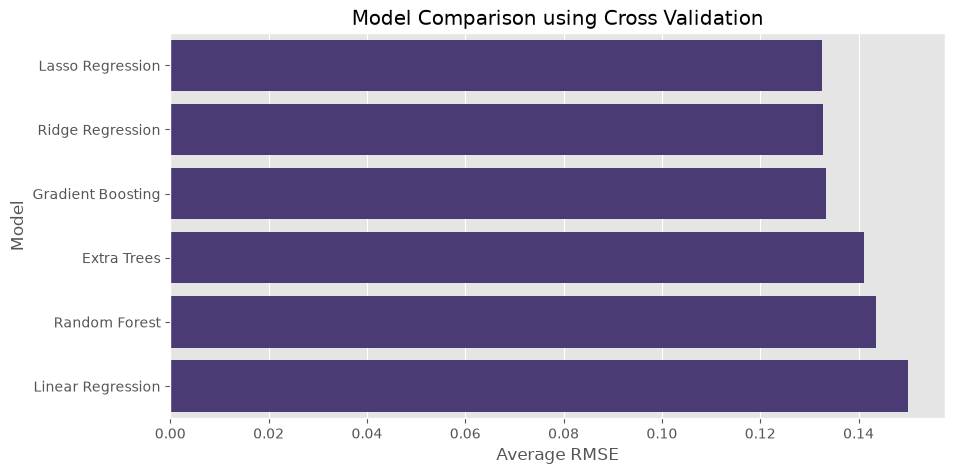

In [50]:
# ==========================================
# Compare Models
# ==========================================

plt.figure(figsize=(10,5))

sns.barplot(

    data=results,

    x="Average RMSE",

    y="Model"

)

plt.title("Model Comparison using Cross Validation")

plt.xlabel("Average RMSE")

plt.show()

In [51]:
# ==========================================
# Select Best Model
# ==========================================

best_model_name = results.iloc[0]["Model"]

print("Best Model :", best_model_name)

Best Model : Lasso Regression


In [52]:
# ==========================================
# Train Best Model
# ==========================================

best_model = models[best_model_name]

best_model.fit(X, y)

print("Best model trained successfully.")

Best model trained successfully.


In [53]:
# ==========================================
# Feature Importance / Coefficients
# ==========================================

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

elif hasattr(best_model, "coef_"):

    importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": np.abs(best_model.coef_)
    })

else:

    importance = None
    print("Feature importance is unavailable for this model.")

if importance is not None:

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    display(importance.head(15))

,Feature,Importance
16,GrLivArea,0.229292
260,TotalHouseArea,0.224969
92,Condition2_PosN,0.165959
78,Neighborhood_StoneBr,0.114876
62,Neighborhood_Crawfor,0.107617
72,Neighborhood_NridgHt,0.084336
71,Neighborhood_NoRidge,0.082749
252,SaleType_New,0.078521
3,LotArea,0.074954
121,Exterior1st_BrkFace,0.067754


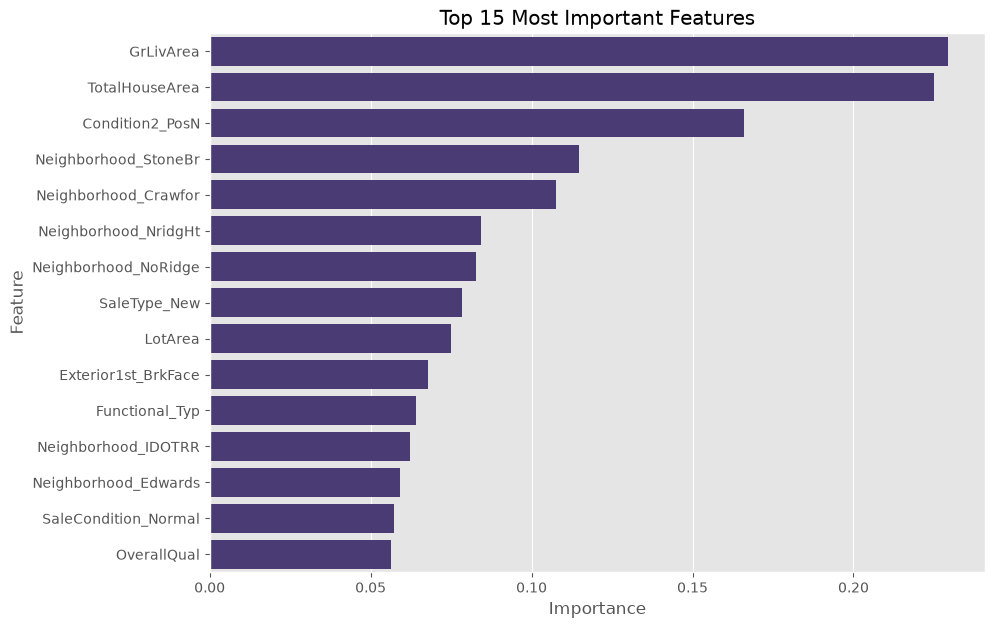

In [54]:
# ==========================================
# Plot Feature Importance
# ==========================================

if importance is not None:

    plt.figure(figsize=(10,7))

    sns.barplot(
        data=importance.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title("Top 15 Most Important Features")

    plt.show()

In [55]:
# ==========================================
# Training Performance
# ==========================================

train_predictions = best_model.predict(X)

rmse = np.sqrt(

    mean_squared_error(

        y,

        train_predictions

    )

)

print("Training RMSE :", round(rmse,5))

Training RMSE : 0.11196


## 📌 Summary

In this section, we trained and evaluated multiple regression models using **5-Fold Cross Validation**.

The models were compared using the **average RMSE**, allowing us to select the most suitable algorithm for predicting house prices.

Among the evaluated models, the one with the **lowest cross-validation RMSE** was chosen as the final model.

Additionally, we explored feature importance (where available) to understand which variables contributed most to the model's predictions.

The selected model is now ready to generate predictions on the unseen test dataset in the final section.

# 📤 Section 7: Prediction, Submission and Conclusion

After training and selecting the best-performing regression model, the final step is to generate predictions for the unseen test dataset.

These predictions will be converted back to the original house price scale and formatted according to Kaggle's submission requirements.

In this section, we will:

- Generate predictions using the selected model.
- Reverse the logarithmic transformation of the target variable.
- Create the submission file.
- Verify the submission format.
- Export the final `submission.csv` file.
- Conclude the project with a summary of the work completed.

The generated submission file can then be uploaded directly to Kaggle for evaluation.

In [56]:
# ==========================================
# Generate Predictions
# ==========================================

predictions = best_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [57]:
# ==========================================
# Reverse Log Transformation
# ==========================================

predictions = np.expm1(predictions)

print("Predictions converted to original SalePrice scale.")

Predictions converted to original SalePrice scale.


In [58]:
# ==========================================
# Create Submission File
# ==========================================

submission = pd.DataFrame({

    "Id": test_df["Id"],

    "SalePrice": predictions

})

submission.head()

,Id,SalePrice
0,1461,13608.191548
1,1462,23361.564333
2,1463,27780.592541
3,1464,28373.670083
4,1465,24897.952207


In [59]:
# ==========================================
# Verify Submission
# ==========================================

print("Submission Shape :", submission.shape)

print("\nMissing Values\n")

print(submission.isnull().sum())

print("\nDuplicate IDs :", submission["Id"].duplicated().sum())

Submission Shape : (1459, 2)

Missing Values

Id           0
SalePrice    0
dtype: int64

Duplicate IDs : 0


In [60]:
# ==========================================
# Save Submission CSV
# ==========================================

submission.to_csv("submission.csv", index=False)

print("=" * 60)
print("submission.csv created successfully!")
print("=" * 60)

submission.csv created successfully!


In [61]:
# ==========================================
# Preview Final Submission
# ==========================================

submission.head(10)

,Id,SalePrice
0,1461,13608.191548
1,1462,23361.564333
2,1463,27780.592541
3,1464,28373.670083
4,1465,24897.952207
5,1466,25651.379319
6,1467,22691.121443
7,1468,22592.736257
8,1469,27356.232056
9,1470,13983.898120


# 🎉 Project Conclusion

Congratulations! We have successfully completed an end-to-end Machine Learning project for the **House Prices: Advanced Regression Techniques** Kaggle competition.

Throughout this notebook, we followed the complete Data Science workflow:

- Imported the required Python libraries.
- Loaded and explored the dataset.
- Performed Exploratory Data Analysis (EDA).
- Cleaned and preprocessed the data.
- Engineered meaningful features.
- Encoded categorical variables.
- Reduced feature skewness.
- Built and compared multiple regression models.
- Evaluated models using 5-Fold Cross Validation.
- Selected the best-performing model.
- Generated predictions for unseen houses.
- Created the final Kaggle submission file.

This project demonstrates how proper data preprocessing, thoughtful feature engineering, and systematic model evaluation contribute to building an effective regression model.

The generated **submission.csv** file is now ready for upload to the Kaggle competition, where its performance will be evaluated on the hidden test dataset.

Thank you for following this notebook. I hope it provided a clear understanding of the complete machine learning workflow for solving a real-world regression problem.

In [62]:
# ==========================================
# End of Notebook
# ==========================================

print("=" * 70)
print("🏠 House Prices Prediction Project Completed Successfully!")
print("📁 submission.csv is ready for Kaggle submission.")
print("🚀 Thank you for exploring this notebook!")
print("=" * 70)

🏠 House Prices Prediction Project Completed Successfully!
📁 submission.csv is ready for Kaggle submission.
🚀 Thank you for exploring this notebook!
